In [1]:
import pandas as pd
import json
import sys
from pathlib import Path
from utils import *
import joblib
from utils.helper_classification import *
# add the directory to the path
sys.path.insert(0, str(Path.cwd()))

### A note regarding DLIF results

Since deep learning models are difficult to reproduce due to system configuration differences, we have provided the predictions files for the models used in the paper. Below you can set the toggle to use our results or use the results from the trained models in `dlif_pipeline/results`.

In [41]:
use_preds = True

# First, run metric evaluations if using our set prediction files
if use_preds:
    generate_dlif_metric_files()


📊 Processing outcome: ORR
  ❌ rwd: Error - Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.
  ❌ rwd_radfm_dp: Error - Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.
  ❌ rwd_radfm: Error -

## PLOT AUC RESULTS

run this section to reproduce **figure 2** and **figure 3** MLEF and DLIF results 

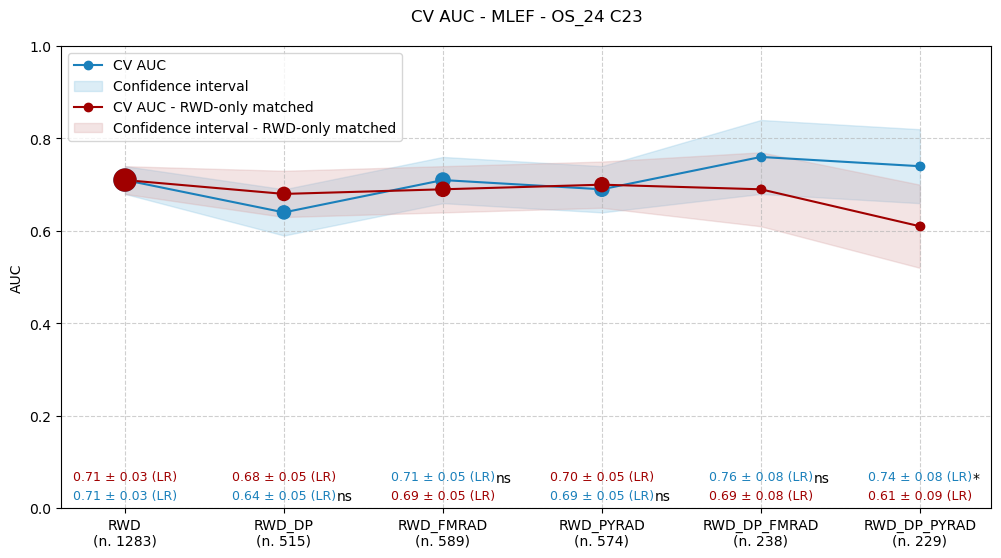

In [6]:
plot_auc_results(
    architecture="MLEF",
    outcome="OS_24",
    analyses=["C23"],
    modality_order=[
        "RWD",
        "RWD_DP",
        "RWD_FMRAD",
        "RWD_PYRAD",
        "RWD_DP_FMRAD",
        "RWD_DP_PYRAD"
    ],
    exclude_modalities=("DP", "FMRAD", "PYRAD"),
    title_prefix=None,
    min_bubble=30,
    max_bubble=250,
    show=True,
    save_dir=None
)

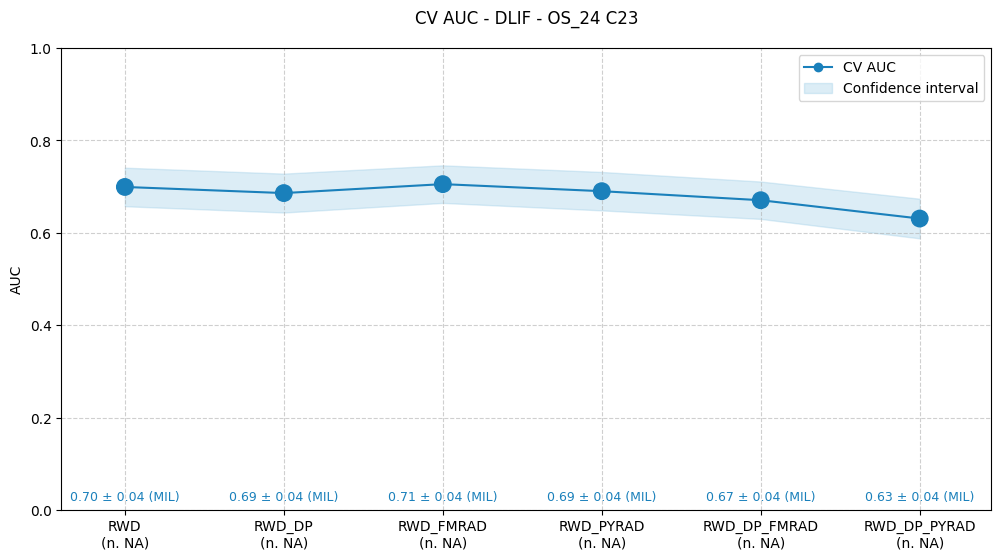

In [4]:
plot_auc_results(
    architecture="DLIF",
    outcome="OS_24",
    analyses=["C23"],
    modality_order=[
        "RWD",
        "RWD_DP",
        "RWD_FMRAD",
        "RWD_PYRAD",
        "RWD_DP_FMRAD",
        "RWD_DP_PYRAD"
    ],
    exclude_modalities=("DP", "FMRAD", "PYRAD", "RWD_RADFM_DP_GENOMICS", "RWD_RADPY_DP_GENOMICS"),
    title_prefix=None,
    min_bubble=30,
    max_bubble=250,
    show=True,
    save_dir=None,
    use_preds = use_preds
)

# BIOMARKER COMPARISON SPIDER PLOT

run this section to reproduce **figure 3** biomarker comparison graphs

Thresholds used to calculate biomarkers: (biomarker >= threshold will be convert into class 1)
- PDL1: 
    - 1 for OS 6, DCR (PDL1 >= 1%); 2 for OS 24 (PDL1 >= 50%)
- NLR: 4
- LDH: 400
- ECOG: 2

Take the real values of the biomarker, remove the missing ones.
According to the outcome (DCR/OS6/OS24) the biomarker will be converted into TP, FP, TN, FN.
Then calculate AUC, accuracy, sensitivity, specificity using as y_true the outcome and y_pred the biomarker.
On the same subset of patients, for each biomarker, use the model to compute the metrics

In [2]:
outcome = 'OS_24' #or 'OS_6' or 'DCR'
modality = 'RWD'

In [23]:
rwd = pd.read_csv('data/rwd.csv')
outcomes = pd.read_csv('data/outcomes.csv')
rwd = rwd.merge(outcomes, on='Subject', how='inner')
test = rwd[rwd['SET'] == 'TEST']
test = test[test[outcome].notna()].reset_index(drop=True)
test.set_index('Subject', inplace=True)
y_pred_mlef = pd.read_csv(f'mlef_pipeline/results/{outcome}/C23/{modality}/prediction_TEST.csv')

In [25]:
if outcome == 'OS_24':
    bio_pdl1 = 'BIO_PDL1_50'
else:
    bio_pdl1 = 'BIO_PDL1_1'

test_biomarkers, biomarkers = add_single_biomarkers(
    outcome=outcome,
    df=test,
    to_show=[bio_pdl1, 'BIO_NLR', 'BIO_LDH', 'BIO_ECOG']
)
test_biomarkers = convert_to_binary(test_biomarkers, biomarkers)
test_biomarkers[[bio_pdl1, 'binary_' + bio_pdl1, 'BIO_NLR', 'binary_BIO_NLR', 'BIO_LDH', 'binary_BIO_LDH', 'BIO_ECOG', 'binary_BIO_ECOG']]

,BIO_PDL1_50,binary_BIO_PDL1_50,BIO_NLR,binary_BIO_NLR,BIO_LDH,binary_BIO_LDH,BIO_ECOG,binary_BIO_ECOG
Subject,,,,,,,,
9,FP,1.0,TN,0.0,TN,0.0,NaN,NaN
14,FP,1.0,TN,0.0,FP,1.0,NaN,NaN
16,TN,0.0,FP,1.0,FP,1.0,NaN,NaN
17,TN,0.0,FP,1.0,FP,1.0,FP,1.0
19,TN,0.0,FP,1.0,FP,1.0,FP,1.0
...,...,...,...,...,...,...,...,...
2059,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0
2063,TN,0.0,FP,1.0,NaN,NaN,FP,1.0
2065,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0


In [26]:
#compute metrics for each biomarker
results = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio.reset_index(drop=True, inplace=True)
    metrics = compute_metrics_biomarker(bio[outcome], bio[biomarker])
    metrics['n.patients'] = len(bio)
    results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


Metrics for binary_BIO_PDL1_50:
AUC: 0.5317, Accuracy: 0.6257, Sensitivity: 0.3333, Specificity: 0.7302

Metrics for binary_BIO_NLR:
AUC: 0.6560, Accuracy: 0.6700, Sensitivity: 0.6275, Specificity: 0.6846

Metrics for binary_BIO_LDH:
AUC: 0.5815, Accuracy: 0.4481, Sensitivity: 0.8837, Specificity: 0.2793

Metrics for binary_BIO_ECOG:
AUC: 0.6177, Accuracy: 0.4515, Sensitivity: 0.9821, Specificity: 0.2533



In [33]:
#compute model metrics on biomarkers subset

mlef_model_results = {}
patients = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()].index
    print(f"Testing model on n. {len(bio)} patients...")
    
    y_pred_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_pred'].values
    y_proba_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_proba'].values
    y_true_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_true'].values
    metrics = compute_metrics(y_true_bio, y_pred_bio, y_proba_bio)
    metrics['n.patients'] = len(bio)
    patients[biomarker] = bio.tolist()
    mlef_model_results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


Testing model on n. 171 patients...
Metrics for binary_BIO_PDL1_50:
AUC: 0.7416, Accuracy: 0.5906, Sensitivity: 0.8889, Specificity: 0.4841

Testing model on n. 200 patients...
Metrics for binary_BIO_NLR:
AUC: 0.7603, Accuracy: 0.6200, Sensitivity: 0.8627, Specificity: 0.5369

Testing model on n. 154 patients...
Metrics for binary_BIO_LDH:
AUC: 0.7523, Accuracy: 0.6234, Sensitivity: 0.8837, Specificity: 0.5225

Testing model on n. 206 patients...
Metrics for binary_BIO_ECOG:
AUC: 0.7476, Accuracy: 0.6117, Sensitivity: 0.8393, Specificity: 0.5267



In [36]:

# Apply DeLong test to compare biomarkers vs ML model
delong_mlef_results = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    print(f"\n=== DeLong Test for {biomarker} vs ML Model ===")
    
    # Get subset of data where biomarker is available
    bio_subset = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio_subjects = bio_subset.index
    
    # Get corresponding test data and model predictions
    test_bio = test[test.index.isin(bio_subjects)]
    y_true_bio = test_bio[outcome].values
    
    # Biomarker predictions (binary, so we use them as probabilities)
    biomarker_preds = bio_subset.loc[test_bio.index, biomarker].values
    
    # ML model predictions (probabilities)
    ml_model_preds = y_pred_mlef[y_pred_mlef['Subject'].isin(bio_subjects)]['y_proba'].values
    print(f"Number of patients in comparison: {len(y_true_bio)}")
    print(f"Number of patients in comparison: {len(biomarker_preds)}")
    
    # Perform DeLong test
    delong_result = delong_test_comparison(y_true_bio, biomarker_preds, ml_model_preds)
    delong_mlef_results[biomarker] = delong_result
    
    # Print results
    print(f"Biomarker AUC: {delong_result['auc1']:.4f} (95% CI: {delong_result['auc1_ci'][0]:.4f}-{delong_result['auc1_ci'][1]:.4f})")
    print(f"ML Model AUC: {delong_result['auc2']:.4f} (95% CI: {delong_result['auc2_ci'][0]:.4f}-{delong_result['auc2_ci'][1]:.4f})")
    print(f"AUC Difference: {delong_result['auc_difference']:.4f}")
    print(f"Z-score: {delong_result['z_score']:.4f}")
    print(f"P-value: {delong_result['p_value']:.6f}")
    print(f"Statistically significant (p < 0.05): {'Yes' if delong_result['significant'] else 'No'}")
    
    if delong_result['significant']:
        if delong_result['auc_difference'] > 0:
            print("→ Biomarker performs significantly better than ML model")
        else:
            print("→ ML model performs significantly better than biomarker")
    else:
        print("→ No significant difference between biomarker and ML model")


=== DeLong Test for binary_BIO_PDL1_50 vs ML Model ===
Number of patients in comparison: 171
Number of patients in comparison: 171
Biomarker AUC: 0.5317 (95% CI: 0.4520-0.6115)
ML Model AUC: 0.7416 (95% CI: 0.6590-0.8243)
AUC Difference: -0.2099
Z-score: -3.6099
P-value: 0.000306
Statistically significant (p < 0.05): Yes
→ ML model performs significantly better than biomarker

=== DeLong Test for binary_BIO_NLR vs ML Model ===
Number of patients in comparison: 200
Number of patients in comparison: 200
Biomarker AUC: 0.6560 (95% CI: 0.5793-0.7328)
ML Model AUC: 0.7603 (95% CI: 0.6829-0.8377)
AUC Difference: -0.1043
Z-score: -3.1246
P-value: 0.001780
Statistically significant (p < 0.05): Yes
→ ML model performs significantly better than biomarker

=== DeLong Test for binary_BIO_LDH vs ML Model ===
Number of patients in comparison: 154
Number of patients in comparison: 154
Biomarker AUC: 0.5815 (95% CI: 0.5174-0.6456)
ML Model AUC: 0.7523 (95% CI: 0.6685-0.8360)
AUC Difference: -0.1708
Z

In [37]:
delong_mlef_summary = []
for biomarker, result in delong_mlef_results.items():
    biomarker_name = biomarker.replace('binary_BIO_', '')
    
    delong_mlef_summary.append({
        'Biomarker': biomarker_name,
        'Biomarker_AUC': f"{result['auc1']:.3f}",
        'Biomarker_CI': f"({result['auc1_ci'][0]:.3f}-{result['auc1_ci'][1]:.3f})",
        'ML_Model_AUC': f"{result['auc2']:.3f}",
        'ML_Model_CI': f"({result['auc2_ci'][0]:.3f}-{result['auc2_ci'][1]:.3f})",
        'AUC_Difference': f"{result['auc_difference']:.3f}",
        'P_value': f"{result['p_value']:.6f}",
        'Significant': 'Yes' if result['significant'] else 'No',
        'Better_Model': 'Biomarker' if result['auc_difference'] > 0 and result['significant'] 
                       else 'ML Model' if result['auc_difference'] < 0 and result['significant']
                       else 'No difference'
    })

delong_mlef = pd.DataFrame(delong_mlef_summary)
print("\n=== DeLong Test Summary (MLEF) ===")
print(delong_mlef.to_string(index=False))



=== DeLong Test Summary (MLEF) ===
Biomarker Biomarker_AUC  Biomarker_CI ML_Model_AUC   ML_Model_CI AUC_Difference  P_value Significant Better_Model
  PDL1_50         0.532 (0.452-0.612)        0.742 (0.659-0.824)         -0.210 0.000306         Yes     ML Model
      NLR         0.656 (0.579-0.733)        0.760 (0.683-0.838)         -0.104 0.001780         Yes     ML Model
      LDH         0.582 (0.517-0.646)        0.752 (0.669-0.836)         -0.171 0.001124         Yes     ML Model
     ECOG         0.618 (0.579-0.657)        0.748 (0.671-0.824)         -0.130 0.001732         Yes     ML Model


In [39]:
biomarker_scores = {
    'PDL1': {k: round(v, 2) for k, v in mlef_model_results['binary_' + bio_pdl1].items()},
    'NLR': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_ECOG'].items()},
}
mlef_model_scores = {
    'PDL1': {k: round(v, 2) for k, v in mlef_model_results['binary_' + bio_pdl1].items()},
    'NLR': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_ECOG'].items()}
}
p_values_mlef = [float(delong_mlef[delong_mlef['Biomarker'] == biomarker]['P_value'].values[0]) for biomarker in ['PDL1_50', 'NLR', 'LDH', 'ECOG']]
size = [
    results['binary_' + bio_pdl1]['n.patients'],
    results['binary_BIO_NLR']['n.patients'],
    results['binary_BIO_LDH']['n.patients'],
    results['binary_BIO_ECOG']['n.patients']
]

In [40]:
# Load DLIF model predictions from parquet file
from sklearn.metrics import roc_auc_score
import numpy as np

outcome_dlif = outcome_to_dlif(outcome)
modality_dlif = map_mlef_to_dlif_modality(modality)

if use_preds:
    predictions_df = pd.read_parquet(f'dlif_pipeline/preds/{outcome_dlif}/classification/standard/{modality_dlif}/predictions.parquet')
else:
    predictions_df = pd.read_parquet(f'dlif_pipeline/results/C23/{outcome_dlif}/classification/standard/hypothesis_driven/pyrad-noimp/{modality_dlif}/seed_0/eval/00000-mb_attention_mil/predictions.parquet')

# Convert non-softmaxed predictions to probabilities using softmax
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Apply softmax to get probabilities
logits = predictions_df[['y_pred0', 'y_pred1']].values
probabilities = softmax(logits)
predictions_df['y_pred_proba'] = probabilities[:, 1]  # Probability of positive class

print(f'Loaded predictions for {len(predictions_df)} patients')
print(f'AUC from loaded predictions: {roc_auc_score(predictions_df["y_true"], predictions_df["y_pred_proba"]):.4f}')



NameError: name 'use_preds' is not defined

In [12]:
# Set up data from DLIF pipeline

annotations = pd.read_csv('data/annotations.csv')
outcome_col_name = "dataset_" + outcome_dlif
test_set = annotations[annotations[outcome_col_name]=='test']['slide'].tolist()

test = rwd[rwd['Subject'].isin(test_set)]
test = test[test[outcome].notna()].reset_index(drop=True)

y_pred_dlif = predictions_df.copy()
test

,Subject,CENTER,SET,AGE AT DIAGNOSIS,AGE AT IO START,SEX,ECOG PS,SMOKING CURRENT,SMOKING FORMER,SMOKING NEVER,...,IO IOCHT_y,HISTOLOGY SQUAMOUS_y,ORR,DCR,CBR,PFS MONTHS,OS MONTHS,TTF MONTHS,OS_6,OS_24
0,9,GHD,TEST,<67,<62,0,NaN,0.0,0.0,1.0,...,0,0.0,0.0,0.0,0.0,2.923784,6.701708,2.036794,1.0,0.0
1,14,GHD,TEST,67-74,>69,1,NaN,0.0,1.0,0.0,...,1,0.0,0.0,0.0,0.0,8.212878,8.212878,3.942181,1.0,0.0
2,16,GHD,TEST,>74,>69,0,NaN,1.0,0.0,0.0,...,1,0.0,0.0,0.0,0.0,1.905388,1.905388,1.314060,0.0,0.0
3,17,GHD,TEST,<67,<62,0,1.0,1.0,0.0,0.0,...,1,0.0,0.0,0.0,0.0,2.956636,8.344284,2.431012,1.0,0.0
4,19,GHD,TEST,<67,<62,1,0.0,0.0,1.0,0.0,...,1,0.0,1.0,1.0,1.0,5.486202,20.926413,5.847569,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,2037,VHIO,TEST,<67,<62,1,1.0,1.0,0.0,0.0,...,1,0.0,1.0,1.0,1.0,25.131406,25.131406,3.350854,1.0,1.0
222,2038,VHIO,TEST,>74,>69,1,1.0,0.0,1.0,0.0,...,0,0.0,1.0,1.0,1.0,60.939553,60.939553,28.810775,1.0,1.0
223,2041,VHIO,TEST,<67,<62,1,1.0,0.0,1.0,0.0,...,0,0.0,1.0,1.0,1.0,114.816032,114.816032,109.296978,1.0,1.0
224,2060,VHIO,TEST,<67,62-69,0,2.0,0.0,1.0,0.0,...,1,0.0,0.0,0.0,0.0,0.229961,0.229961,0.229961,0.0,0.0


In [13]:
if outcome == 'OS_24':
    bio_pdl1 = 'BIO_PDL1_50'
else:
    bio_pdl1 = 'BIO_PDL1_1'

test_biomarkers, biomarkers = add_single_biomarkers(
    outcome=outcome,
    df=test,
    to_show=[bio_pdl1, 'BIO_NLR', 'BIO_LDH', 'BIO_ECOG']
)
print("test_biomarkers columns:", test_biomarkers.columns.tolist())
print("biomarkers list:", biomarkers)

test_biomarkers = convert_to_binary(test_biomarkers, biomarkers)
test_biomarkers[[bio_pdl1, 'binary_' + bio_pdl1, 'BIO_NLR', 'binary_BIO_NLR', 'BIO_LDH', 'binary_BIO_LDH', 'BIO_ECOG', 'binary_BIO_ECOG']]

test_biomarkers columns: ['Subject', 'CENTER', 'SET', 'AGE AT DIAGNOSIS', 'AGE AT IO START', 'SEX', 'ECOG PS', 'SMOKING CURRENT', 'SMOKING FORMER', 'SMOKING NEVER', 'EVER SMOKED', 'SMOKING PACKYEAR CUTOFF 10', 'SMOKING PACKSYEAR', 'HISTOLOGY ADENOCARCINOMA', 'HISTOLOGY SQUAMOUS_x', 'HISTOLOGY OTHER', 'PDL1 CATEGORY', 'T DIAGNOSIS', 'N DIAGNOSIS', 'M DIAGNOSIS', 'DIAG STAGE', 'T AT IO START', 'N AT IO START', 'M AT IO START', 'IO LINE_x', 'RACE', 'STAGE AT IO START', 'PARENCHYMAL BRAIN METS AT IO START', 'LIVER METS AT IO START', 'BONE METS AT IO START', 'ADRENAL METS AT IO START', 'BONE MARROW METS AT IO START', 'LEPTOMENINGEAL METS AT IO START', 'LUNG METS AT IO START', 'LYMPH NODES METS AT IO START', 'PERICARDIAL EFFUSION METS AT IO START', 'PLEURA METS AT IO START', 'PLEURAL EFFUSION METS AT IO START', 'SKIN METS AT IO START', 'SOFT TISSUE METS AT IO START', 'OTHER METS AT IO START', 'SURGERY', 'LDH', 'NEUTROPHYL', 'MONOCYTE', 'LYMPHOCYTES', 'NLR', 'BMI', 'IO IOCHT_x', 'IO IN NEOADJ

,BIO_PDL1_50,binary_BIO_PDL1_50,BIO_NLR,binary_BIO_NLR,BIO_LDH,binary_BIO_LDH,BIO_ECOG,binary_BIO_ECOG
0,FP,1.0,TN,0.0,TN,0.0,NaN,NaN
1,FP,1.0,TN,0.0,FP,1.0,NaN,NaN
2,TN,0.0,FP,1.0,FP,1.0,NaN,NaN
3,TN,0.0,FP,1.0,FP,1.0,FP,1.0
4,TN,0.0,FP,1.0,FP,1.0,FP,1.0
...,...,...,...,...,...,...,...,...
221,FN,0.0,FN,0.0,NaN,NaN,TP,1.0
222,TP,1.0,TP,1.0,FN,0.0,TP,1.0
223,TP,1.0,NaN,NaN,NaN,NaN,TP,1.0
224,TN,0.0,TN,0.0,NaN,NaN,TN,0.0


In [14]:
#compute metrics for each biomarker
results = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio.reset_index(drop=True, inplace=True)
    metrics = compute_metrics_biomarker(bio[outcome], bio[biomarker])
    metrics['n.patients'] = len(bio)
    results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


Metrics for binary_BIO_PDL1_50:
AUC: 0.5317, Accuracy: 0.6257, Sensitivity: 0.3333, Specificity: 0.7302

Metrics for binary_BIO_NLR:
AUC: 0.6560, Accuracy: 0.6700, Sensitivity: 0.6275, Specificity: 0.6846

Metrics for binary_BIO_LDH:
AUC: 0.5815, Accuracy: 0.4481, Sensitivity: 0.8837, Specificity: 0.2793

Metrics for binary_BIO_ECOG:
AUC: 0.6177, Accuracy: 0.4515, Sensitivity: 0.9821, Specificity: 0.2533



In [16]:
# Test DLIF model predictions on biomarkers subset using loaded predictions from parquet
dl_model_results = {}
patients = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    # Get patients where biomarker is available
    bio_patients = test_biomarkers[test_biomarkers[biomarker].notna()]['Subject']
    print(bio_patients)
    print(f"Testing DLIF model on n. {len(bio_patients)} patients...")
    
    # Match with predictions data using slide column
    predictions_subset = predictions_df[predictions_df['slide'].isin(bio_patients)]
    
    # Get true labels and predicted probabilities
    y_true_bio = predictions_subset['y_true'].values
    y_proba_bio = predictions_subset['y_pred_proba'].values
    y_pred_bio = (y_proba_bio >= 0.5).astype(int)
    
    # Calculate metrics
    metrics = compute_metrics(y_true_bio, y_pred_bio, y_proba_bio)
    metrics['n.patients'] = len(predictions_subset)
    patients[biomarker] = bio_patients.tolist()
    dl_model_results[biomarker] = metrics
    
    print(f"DLIF Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")

0         9
1        14
2        16
3        17
4        19
       ... 
219    2032
221    2037
222    2038
223    2041
224    2060
Name: Subject, Length: 171, dtype: int64
Testing DLIF model on n. 171 patients...


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [ ]:

# Apply DeLong test to compare biomarkers vs DLIF model using loaded predictions
delong_results_dl = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    print(f"\n=== DeLong Test for {biomarker} vs DLIF Model ===")
    
    # Get subset of data where biomarker is available
    bio_subset = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio_subjects = bio_subset['Subject']
    
    # Get corresponding predictions data
    predictions_subset = predictions_df[predictions_df['slide'].isin(bio_subjects)]
    
    # Match biomarker data with predictions by Subject/slide
    merged_data = bio_subset.merge(predictions_subset, left_on='Subject', right_on='slide', how='inner')
    
    y_true_bio = merged_data['y_true'].values
    
    # Biomarker predictions (binary, so we use them as probabilities)  
    biomarker_preds = merged_data[biomarker].values
    
    # DLIF model predictions (probabilities)
    dl_model_preds = merged_data['y_pred_proba'].values
    
    # Perform DeLong test
    delong_result = delong_test_comparison(y_true_bio, biomarker_preds, dl_model_preds)
    delong_results_dl[biomarker] = delong_result
    
    # Print results
    print(f"Biomarker AUC: {delong_result['auc1']:.4f} (95% CI: {delong_result['auc1_ci'][0]:.4f}-{delong_result['auc1_ci'][1]:.4f})")
    print(f"DLIF Model AUC: {delong_result['auc2']:.4f} (95% CI: {delong_result['auc2_ci'][0]:.4f}-{delong_result['auc2_ci'][1]:.4f})")
    print(f"AUC Difference: {delong_result['auc_difference']:.4f}")
    print(f"Z-score: {delong_result['z_score']:.4f}")
    print(f"P-value: {delong_result['p_value']:.6f}")
    print(f"Statistically significant (p < 0.05): {'Yes' if delong_result['significant'] else 'No'}")
    
    if delong_result['significant']:
        if delong_result['auc_difference'] > 0:
            print("→ Biomarker performs significantly better than DLIF model")
        else:
            print("→ DLIF model performs significantly better than biomarker")
    else:
        print("→ No significant difference between biomarker and DLIF model")


=== DeLong Test for binary_BIO_PDL1_1 vs DLIF Model ===
Biomarker AUC: 0.5259 (95% CI: 0.4593-0.5926)
DLIF Model AUC: 0.6307 (95% CI: 0.5541-0.7072)
AUC Difference: -0.1047
Z-score: -2.0498
P-value: 0.040389
Statistically significant (p < 0.05): Yes
→ DLIF model performs significantly better than biomarker

=== DeLong Test for binary_BIO_NLR vs DLIF Model ===
Biomarker AUC: 0.5902 (95% CI: 0.5277-0.6526)
DLIF Model AUC: 0.6425 (95% CI: 0.5701-0.7149)
AUC Difference: -0.0523
Z-score: -1.1890
P-value: 0.234420
Statistically significant (p < 0.05): No
→ No significant difference between biomarker and DLIF model

=== DeLong Test for binary_BIO_LDH vs DLIF Model ===
Biomarker AUC: 0.5945 (95% CI: 0.5337-0.6553)
DLIF Model AUC: 0.6550 (95% CI: 0.5737-0.7363)
AUC Difference: -0.0605
Z-score: -1.3006
P-value: 0.193383
Statistically significant (p < 0.05): No
→ No significant difference between biomarker and DLIF model

=== DeLong Test for binary_BIO_ECOG vs DLIF Model ===
Biomarker AUC: 0.610

In [ ]:
# Create a summary table of DeLong test results for DLIF model
delong_summary_dl = []
for biomarker, result in delong_results_dl.items():
    biomarker_name = biomarker.replace('binary_BIO_', '')
    
    delong_summary_dl.append({
        'Biomarker': biomarker_name,
        'Biomarker_AUC': f"{result['auc1']:.3f}",
        'Biomarker_CI': f"({result['auc1_ci'][0]:.3f}-{result['auc1_ci'][1]:.3f})",
        'DLIF_Model_AUC': f"{result['auc2']:.3f}",
        'DLIF_Model_CI': f"({result['auc2_ci'][0]:.3f}-{result['auc2_ci'][1]:.3f})",
        'AUC_Difference': f"{result['auc_difference']:.3f}",
        'P_value': f"{result['p_value']:.6f}",
        'Significant': 'Yes' if result['significant'] else 'No',
        'Better_Model': 'Biomarker' if result['auc_difference'] > 0 and result['significant'] 
                       else 'DLIF Model' if result['auc_difference'] < 0 and result['significant']
                       else 'No difference'
    })

delong_df_dl = pd.DataFrame(delong_summary_dl)
print("\n=== DeLong Test Summary (DLIF) ===")
print(delong_df_dl.to_string(index=False))


=== DeLong Test Summary (DLIF) ===
Biomarker Biomarker_AUC  Biomarker_CI DLIF_Model_AUC DLIF_Model_CI AUC_Difference  P_value Significant  Better_Model
   PDL1_1         0.526 (0.459-0.593)          0.631 (0.554-0.707)         -0.105 0.040389         Yes    DLIF Model
      NLR         0.590 (0.528-0.653)          0.642 (0.570-0.715)         -0.052 0.234420          No No difference
      LDH         0.595 (0.534-0.655)          0.655 (0.574-0.736)         -0.060 0.193383          No No difference
     ECOG         0.611 (0.558-0.663)          0.650 (0.578-0.721)         -0.039 0.266493          No No difference


In [ ]:
# DLIF model scores 
dlif_scores = {
    'PDL1': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_PDL1_1'].items()},
    'NLR': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_ECOG'].items()}
}
p_values_dl = [float(delong_df_dl[delong_df_dl['Biomarker'] == biomarker]['P_value'].values[0]) for biomarker in ['PDL1_1', 'NLR', 'LDH', 'ECOG']]  # DLIF p-values

In [ ]:
biomarkers = ['PDL1', 'NLR', 'LDH', 'ECOG']

metrics = ['AUC', 'Accuracy', 'Sensitivity', 'Specificity']
path = 'Biomarker_comparison'
plot_radar_charts(
    biomarker_scores=biomarker_scores,
    model_scores=mlef_model_scores,
    dl_scores=dlif_scores,
    p_values_ml=p_values_mlef,
    p_values_dl=p_values_dl,
    size=size,
    biomarkers=biomarkers,
    metrics=metrics,
    title_prefix=f'{outcome} Model'
)


NameError: name 'biomarker_scores' is not defined

# FARINESS RESULTS PLOT

run this section to reproduce **figure 4** fairness graphs

In [ ]:
# Configuration for each outcome
# Predictions are loaded from: mlef_pipeline/results/{outcome}/C23/RWD/prediction_test.csv
OUTCOME_CONFIG = {
    'OS 24': {
        'outcome': 'OS_24',
        'outcome_name': 'OS 24'
    },
     'OS 6': {
        'outcome': 'OS_6',
        'outcome_name': 'OS 6'
    },
    'DCR': {
        'outcome': 'DCR',              
        'outcome_name': 'DCR'         
    }
    
}

# Base path where MLEF folder is located
BASE_PATH = 'mlef_pipeline/results'

# These will be computed automatically from the data
PATIENTS_PER_OUTCOME = {}
OUTCOME_THRESHOLDS_TPR = {}
OUTCOME_THRESHOLDS_FPR = {}

In [ ]:
# Run analysis for all outcomes
all_results = {}

for outcome_display_name, config in OUTCOME_CONFIG.items():
    results = analyze_outcome_fairness(
        outcome=config['outcome'],
        outcome_name=config['outcome_name'],
        base_path=BASE_PATH,
        n_perms=1000,
        random_state=42
    )
    all_results[outcome_display_name] = results
    
    # Populate thresholds and patient counts automatically
    OUTCOME_THRESHOLDS_TPR[outcome_display_name] = results['threshold_tpr']
    OUTCOME_THRESHOLDS_FPR[outcome_display_name] = results['threshold_fpr']
    PATIENTS_PER_OUTCOME[outcome_display_name] = results['patients_per_center']

print("\n" + "="*60)
print("Analysis completed for all outcomes!")
print("="*60)
print("\nComputed Thresholds:")
print(f"  TPR: {OUTCOME_THRESHOLDS_TPR}")
print(f"  FPR: {OUTCOME_THRESHOLDS_FPR}")
print(f"\nPatients per outcome (by center):")
for outcome, counts in PATIENTS_PER_OUTCOME.items():
    print(f"  {outcome}: {counts}")


Analyzing OS 24

Loaded predictions for OS_24:
  Samples: 226
  Columns in test data: 3 (CENTER, SEX, RACE)
  Subject order preserved: True
Overall Test Performance:
  AUC: 0.681
  TPR (threshold): 0.850
  FPR (threshold): 0.488

Analyzing fairness by center...
Patients per center: {'INT': 97, 'GHD': 63, 'VHIO': 29, 'SZMC': 20, 'MH': 17}
Patients per sex: {1: 141, 0: 85}


Sex-based fairness analysis (test set)...
  TPR - Female: 0.960, Male: 0.771, p=0.0579
  FPR - Female: 0.550, Male: 0.453, p=0.2607

Center-based fairness analysis...
  TPR omnibus p-value: 0.1139
  FPR omnibus p-value: 0.4815

Analyzing OS 6

Loaded predictions for OS_6:
  Samples: 259
  Columns in test data: 3 (CENTER, SEX, RACE)
  Subject order preserved: True
Overall Test Performance:
  AUC: 0.642
  TPR (threshold): 0.648
  FPR (threshold): 0.364

Analyzing fairness by center...
Patients per center: {'INT': 101, 'GHD': 65, 'SZMC': 36, 'VHIO': 31, 'MH': 26}
Patients per sex: {1: 166, 0: 93}


Sex-based fairness a

In [ ]:
# Create summary tables
sex_fairness, center_fairness, pairwise_tpr, pairwise_fpr = create_fairness_summary(all_results)

print("Sex-based fairness summary:")
display(sex_fairness)

print("\nCenter-based fairness summary:")
display(center_fairness)

Sex-based fairness summary:


,Metric,Sex,Value,CI,p-value,outcome
0,TPR,Female,0.960000,"(0.88, 1.0)",0.057942,OS 24
1,TPR,Male,0.771429,"(0.63, 0.91)",0.057942,OS 24
2,FPR,Female,0.550000,"(0.43, 0.68)",0.260739,OS 24
3,FPR,Male,0.452830,"(0.35, 0.55)",0.260739,OS 24
4,TPR,Female,0.714286,"(0.6, 0.83)",0.203796,OS 6
5,TPR,Male,0.613445,"(0.53, 0.71)",0.203796,OS 6
6,FPR,Female,0.433333,"(0.27, 0.6)",0.317682,OS 6
7,FPR,Male,0.319149,"(0.19, 0.45)",0.317682,OS 6
8,TPR,Female,0.796610,"(0.68, 0.9)",0.150849,DCR
9,TPR,Male,0.681818,"(0.59, 0.77)",0.150849,DCR



Center-based fairness summary:


,TPR,TPR_ci_lower,TPR_ci_upper,FPR,FPR_ci_lower,FPR_ci_upper,outcome,TPR_omnibus_p,FPR_omnibus_p
center,,,,,,,,,
GHD,0.875000,0.62,1.00,0.509091,0.36,0.65,OS 24,0.113886,0.481518
GHD,0.619048,0.48,0.74,0.565217,0.35,0.74,OS 6,0.015984,0.033966
GHD,0.727273,0.58,0.88,0.531250,0.34,0.69,DCR,0.023976,0.119880
INT,0.833333,0.70,0.97,0.417910,0.30,0.52,OS 24,0.113886,0.481518
INT,0.578125,0.45,0.69,0.270270,0.14,0.41,OS 6,0.015984,0.033966
INT,0.631579,0.51,0.75,0.318182,0.18,0.45,DCR,0.023976,0.119880
MH,1.000000,1.00,1.00,0.666667,0.33,0.89,OS 24,0.113886,0.481518
MH,0.958333,0.88,1.00,0.500000,0.00,1.00,OS 6,0.015984,0.033966
MH,0.964286,0.89,1.00,0.714286,0.29,1.00,DCR,0.023976,0.119880


Failed to add labels: 'ErrorbarContainer' object has no attribute 'patches'


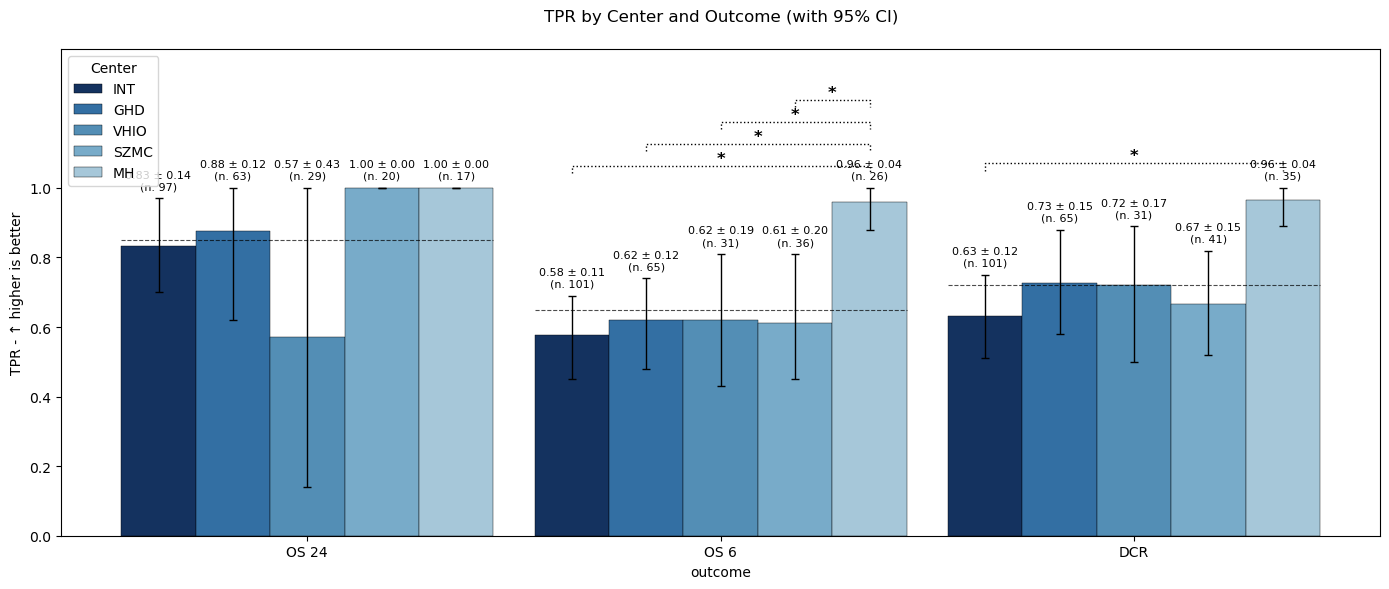

In [ ]:
# Plot TPR by center
plot_fairness_by_center(
    center_fairness=center_fairness,
    pairwise_tpr=pairwise_tpr,
    pairwise_fpr=pairwise_fpr,
    metric='TPR',
    patients_per_outcome=PATIENTS_PER_OUTCOME,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR
)

Failed to add labels: 'ErrorbarContainer' object has no attribute 'patches'


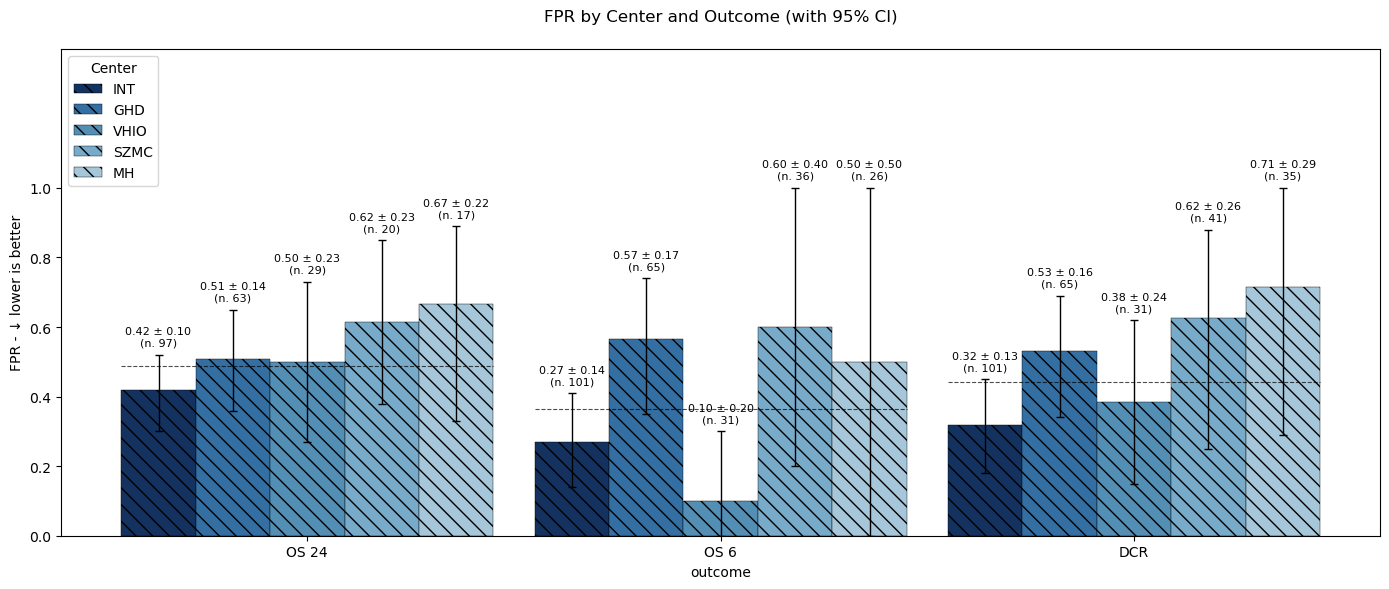

In [ ]:
# Plot FPR by center
plot_fairness_by_center(
    center_fairness=center_fairness,
    pairwise_tpr=pairwise_tpr,
    pairwise_fpr=pairwise_fpr,
    metric='FPR',
    patients_per_outcome=PATIENTS_PER_OUTCOME,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR
)

Patients per sex:
  OS 24: {'Female': 85, 'Male': 141}
  OS 6: {'Female': 93, 'Male': 166}
  DCR: {'Female': 98, 'Male': 175}
Failed to add labels: 'ErrorbarContainer' object has no attribute 'patches'


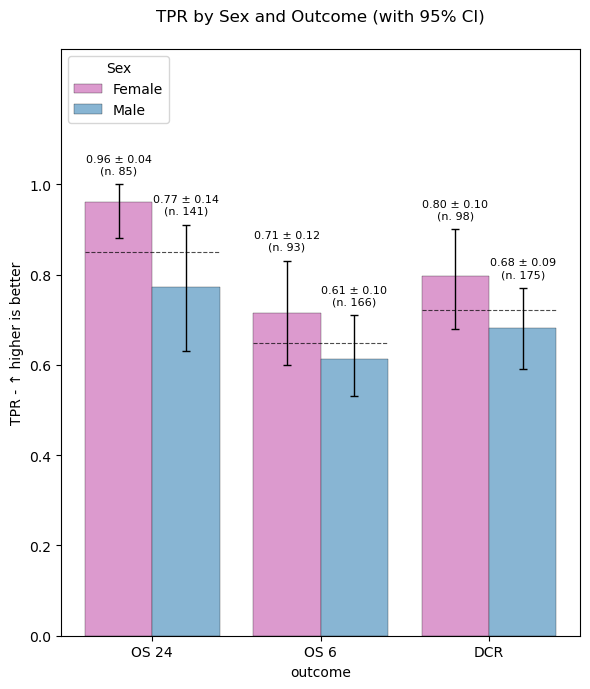

In [ ]:
# Compute sex patient counts from results
sex_patients = {}
for outcome_name, results in all_results.items():
    sex_counts = results['patients_per_sex']
    # Map numeric values to labels (assuming 0=Female, 1=Male)
    sex_patients[outcome_name] = {
        'Female': sex_counts.get(0, 0),
        'Male': sex_counts.get(1, 0)
    }

print("Patients per sex:")
for outcome, counts in sex_patients.items():
    print(f"  {outcome}: {counts}")

# Plot TPR by sex (test set)
plot_fairness_by_group(
    fairness_df=sex_fairness,
    metric='TPR',
    group_col='Sex',
    patients_per_outcome=sex_patients,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR
)

Failed to add labels: 'ErrorbarContainer' object has no attribute 'patches'


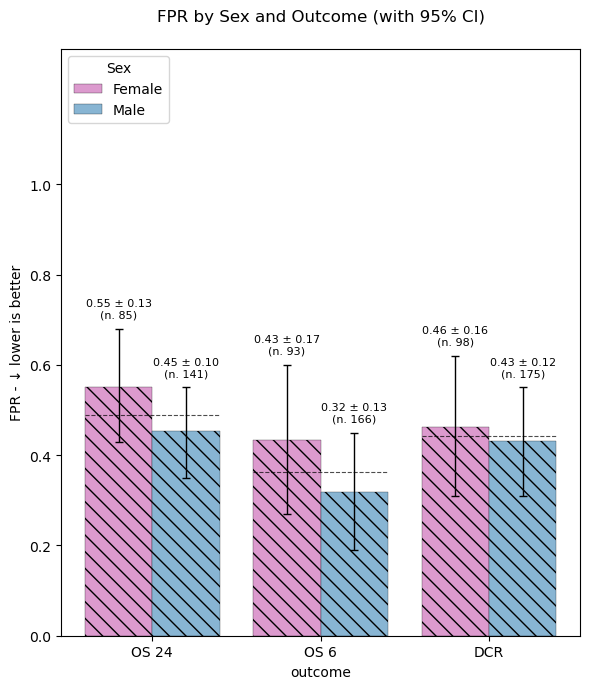

In [ ]:
# Plot FPR by sex (test set)
plot_fairness_by_group(
    fairness_df=sex_fairness,
    metric='FPR',
    group_col='Sex',
    patients_per_outcome=sex_patients,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR
)

# GLOBAL XAI
run this section to reproduce **figure 4** XAI graphs

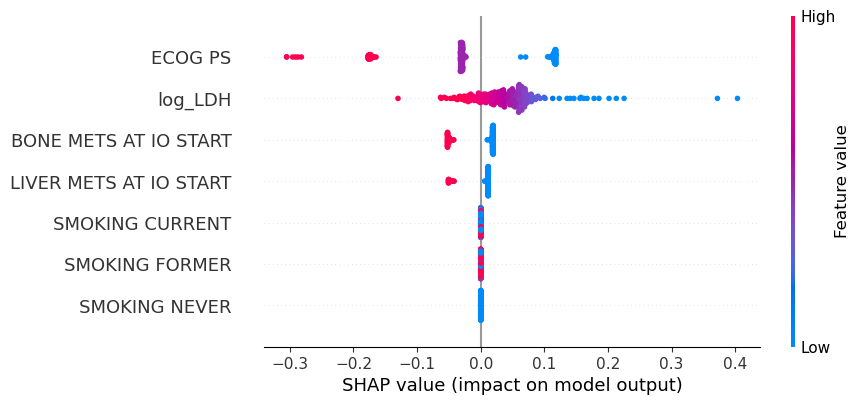

In [ ]:
outcome = 'DCR' #   'OS_6' | 'OS_24' | 'DCR'
model = joblib.load(f'mlef_pipeline/results/{outcome}/C23/RWD/model_LR.pkl')  # model_LR or model_RF
train = pd.read_csv(f'mlef_pipeline/results/{outcome}/C23/RWD/train_set.csv')
test = pd.read_csv(f'mlef_pipeline/results/{outcome}/C23/RWD/test_set.csv')
X_tr = train[model.feature_names_in_]
X_test = test[model.feature_names_in_]
shap_beeswarm(model, X_tr, X_test)